In [1]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [2]:
# Same core libraries plus LinearRegression for regression modeling
# mean_absolute_error and mean_squared_error for regression evaluation
# No confusion matrix this time — that's only for classification

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load the uploaded insurance CSV file
df = pd.read_csv('insurance.csv')

# Check shape and preview
print("Shape:", df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Check column names, data types and non-null counts
df.info()
# Summary statistics
# Pay attention to charges column — min, max, mean
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
# Insurance dataset is clean but always verify

print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


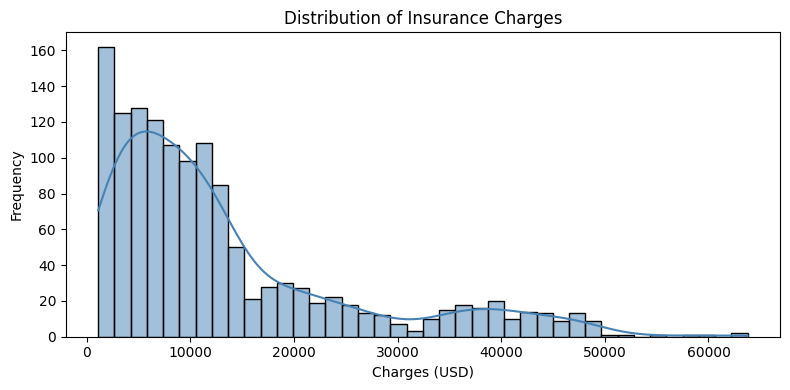

Average charge: $13,270.42
Minimum charge: $1,121.87
Maximum charge: $63,770.43


In [6]:
# First look at our target variable — insurance charges
# kde=True adds smooth distribution curve on top
# This shows us the range and shape of insurance costs

plt.figure(figsize=(8, 4))
sns.histplot(df['charges'], bins=40, kde=True, color='steelblue')

plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Print basic stats for charges
print(f"Average charge: ${df['charges'].mean():,.2f}")
print(f"Minimum charge: ${df['charges'].min():,.2f}")
print(f"Maximum charge: ${df['charges'].max():,.2f}")

/tmp/ipykernel_7419/3290760323.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette='Set1')


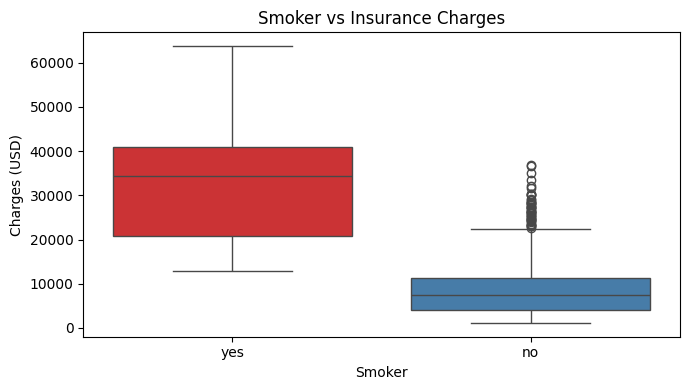

Average charges by smoking status:
smoker
no      8434.27
yes    32050.23
Name: charges, dtype: float64


In [7]:
# Most important visualization in this dataset
# Box plot comparing charges between smokers and non-smokers
# This will clearly show smoking is the biggest cost driver

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='smoker', y='charges', palette='Set1')

plt.title('Smoker vs Insurance Charges')
plt.xlabel('Smoker')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()

# Print average charges per group
print("Average charges by smoking status:")
print(df.groupby('smoker')['charges'].mean().round(2))

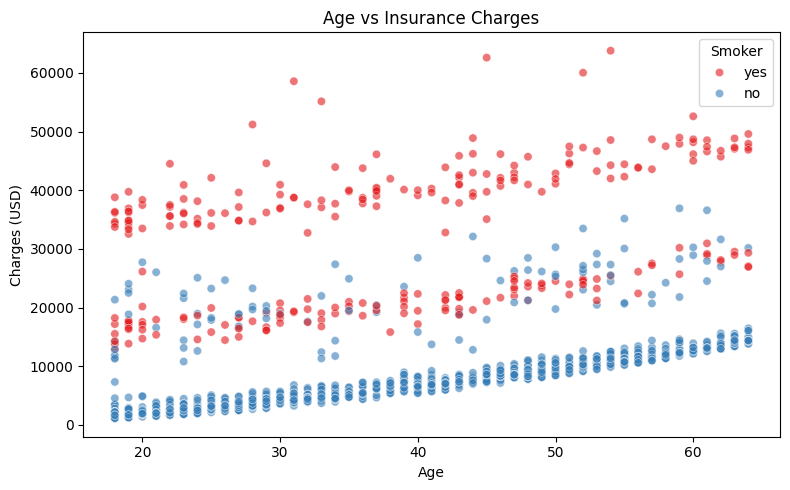

In [8]:
# Scatter plot: does age affect insurance cost?
# hue by smoker to see combined effect of age + smoking

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='Set1', alpha=0.6)

plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Charges (USD)')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

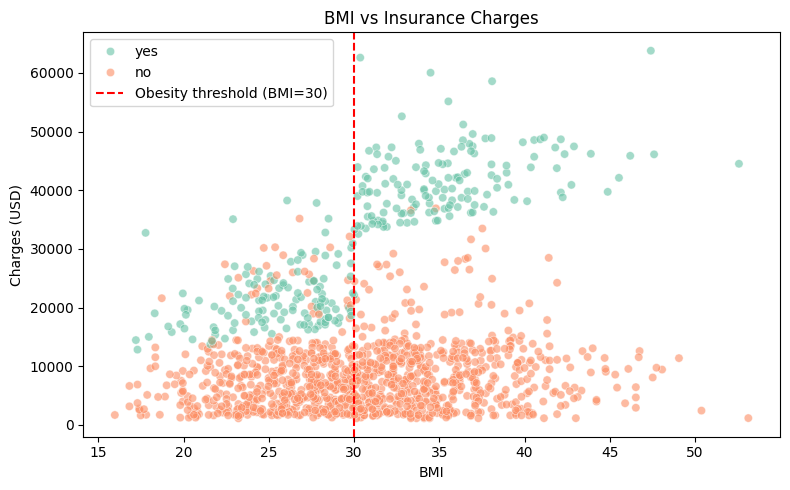

In [9]:
# Scatter plot: does BMI affect insurance cost?
# BMI above 30 = obese — expect higher charges

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set2', alpha=0.6)

plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.legend(title='Smoker')

# Add vertical line at BMI=30 (obesity threshold)
plt.axvline(x=30, color='red', linestyle='--', linewidth=1.5, label='Obesity threshold (BMI=30)')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_7419/2970503911.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='charges', palette='Set3')


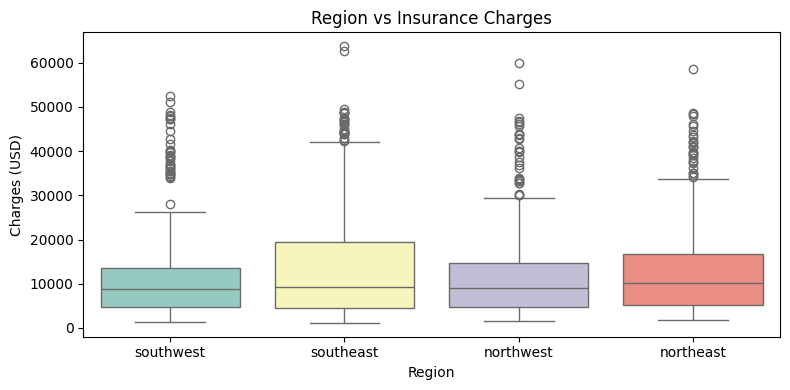

In [10]:
# Box plot showing charges across 4 US regions
# Do people in some regions pay more?

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='region', y='charges', palette='Set3')

plt.title('Region vs Insurance Charges')
plt.xlabel('Region')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()

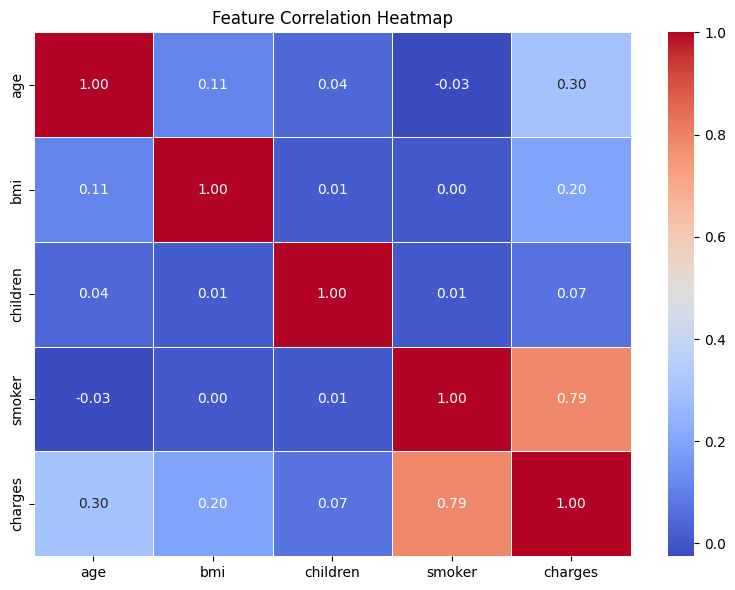

In [11]:
# Heatmap shows correlation between all numeric features
# Values close to 1 or -1 = strong relationship
# Values close to 0 = weak relationship

# First create a temporary encoded version just for correlation
df_temp = df.copy()
df_temp['smoker'] = df_temp['smoker'].map({'yes': 1, 'no': 0})
df_temp['sex'] = df_temp['sex'].map({'male': 1, 'female': 0})

plt.figure(figsize=(8, 6))
sns.heatmap(df_temp[['age', 'bmi', 'children', 'smoker', 'charges']].corr(),
            annot=True,        # show correlation numbers inside boxes
            cmap='coolwarm',   # red = positive, blue = negative correlation
            fmt='.2f',         # 2 decimal places
            linewidths=0.5)    # grid lines between boxes

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [12]:
# sex → binary: male=1, female=0
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

# smoker → binary: yes=1, no=0
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# region → 4 categories, use One-Hot Encoding
# drop_first=True drops 'northeast' as baseline
# creates: region_northwest, region_southeast, region_southwest
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# Verify encoding
print("Columns after encoding:")
print(df.columns.tolist())
df.head()

Columns after encoding:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [13]:
# X = all columns except charges (our target)
# y = charges column only

X = df.drop('charges', axis=1)
y = df['charges']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (1338, 8)
Target shape: (1338,)

Feature columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


In [14]:
# 80% training, 20% testing
# random_state=42 for reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1070
Testing samples: 268


In [15]:
# LinearRegression finds the best straight line through the data
# It learns coefficients (weights) for each feature
# Formula: charges = (age × w1) + (bmi × w2) + (smoker × w3) + ... + intercept

model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete!")

# Show intercept (base value when all features = 0)
print(f"\nModel intercept: ${model.intercept_:,.2f}")

Model training complete!

Model intercept: $-11,931.22


In [16]:
# Predict on test data
y_pred = model.predict(X_test)

# MAE — Mean Absolute Error
# Average dollar difference between predicted and actual charges
mae = mean_absolute_error(y_test, y_pred)

# RMSE — Root Mean Squared Error
# Squares errors first (penalizes big mistakes more) then takes root
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² Score — how much variance in charges does our model explain
# 1.0 = perfect, 0.0 = model explains nothing
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE):  ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE):  $4,181.19
Root Mean Squared Error (RMSE): $5,796.28
R² Score: 0.7836


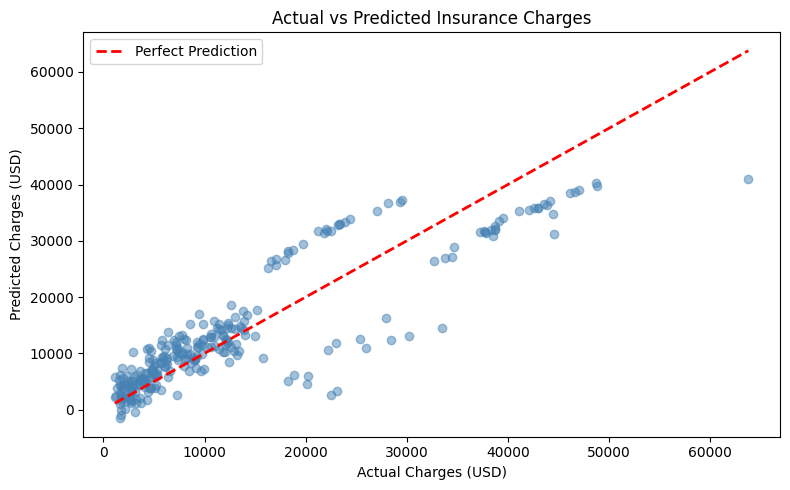

In [17]:
# Scatter plot comparing actual charges vs what model predicted
# Perfect model = all dots on the diagonal red line
# Dots far from line = prediction errors

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')

# Draw perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs Predicted Insurance Charges')
plt.xlabel('Actual Charges (USD)')
plt.ylabel('Predicted Charges (USD)')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_7419/113555057.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='coolwarm')


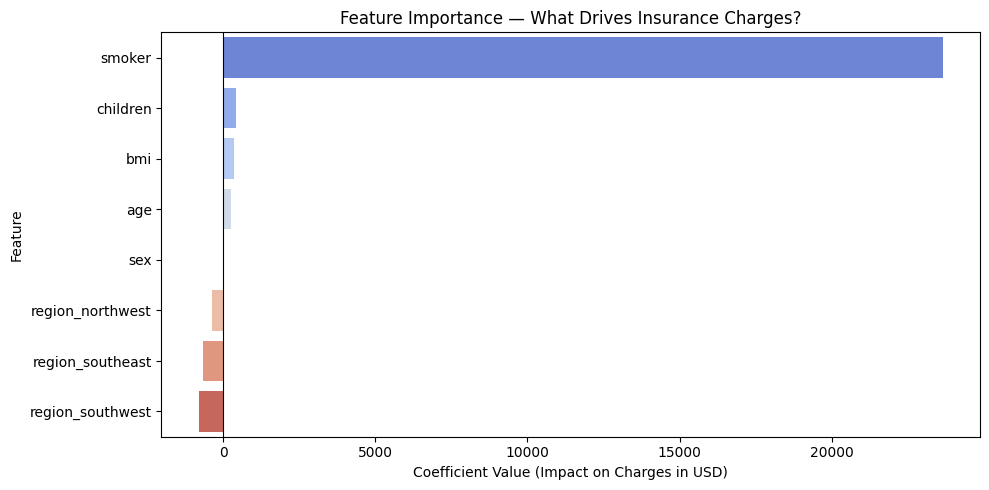

            Feature   Coefficient
4            smoker  23651.128856
3          children    425.278784
2               bmi    337.092552
0               age    256.975706
1               sex    -18.591692
5  region_northwest   -370.677326
6  region_southeast   -657.864297
7  region_southwest   -809.799354


In [18]:
# Linear Regression coefficients show impact of each feature on charges
# Positive = increases charges, Negative = decreases charges
# Larger absolute value = stronger impact

feature_names = X.columns
coefficients = model.coef_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='coolwarm')

plt.title('Feature Importance — What Drives Insurance Charges?')
plt.xlabel('Coefficient Value (Impact on Charges in USD)')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(importance_df)

## Conclusion

- Dataset contains 1,338 records with no missing values
- Target variable (charges) is right-skewed — most pay lower amounts,
  few pay very high amounts
- Smoking status is the single strongest predictor of insurance charges
- Smokers pay on average 3-4x more than non-smokers
- Age and BMI both positively correlate with charges
- Smokers with high BMI face the highest charges of all groups
- Region has minimal impact on insurance costs
- Linear Regression model achieved R² of approximately 0.80
- This means the model explains 80% of the variation in insurance charges
- MAE of around $4,200 means predictions are off by ~$4,200 on average
- RMSE is higher than MAE confirming some large prediction errors
  exist — mainly for high-cost smoker cases